In [22]:
import warnings
warnings.filterwarnings("ignore")

In [23]:
!pip install rasterio

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import seaborn as sns

In [5]:
IMAGE_DIR = "/kaggle/input/harmonized-sentinel-landsat-water-dataset/data/images"
LABEL_DIR = "/kaggle/input/harmonized-sentinel-landsat-water-dataset/data/labels"

Image shape: (12, 128, 128)
Label shape: (128, 128)


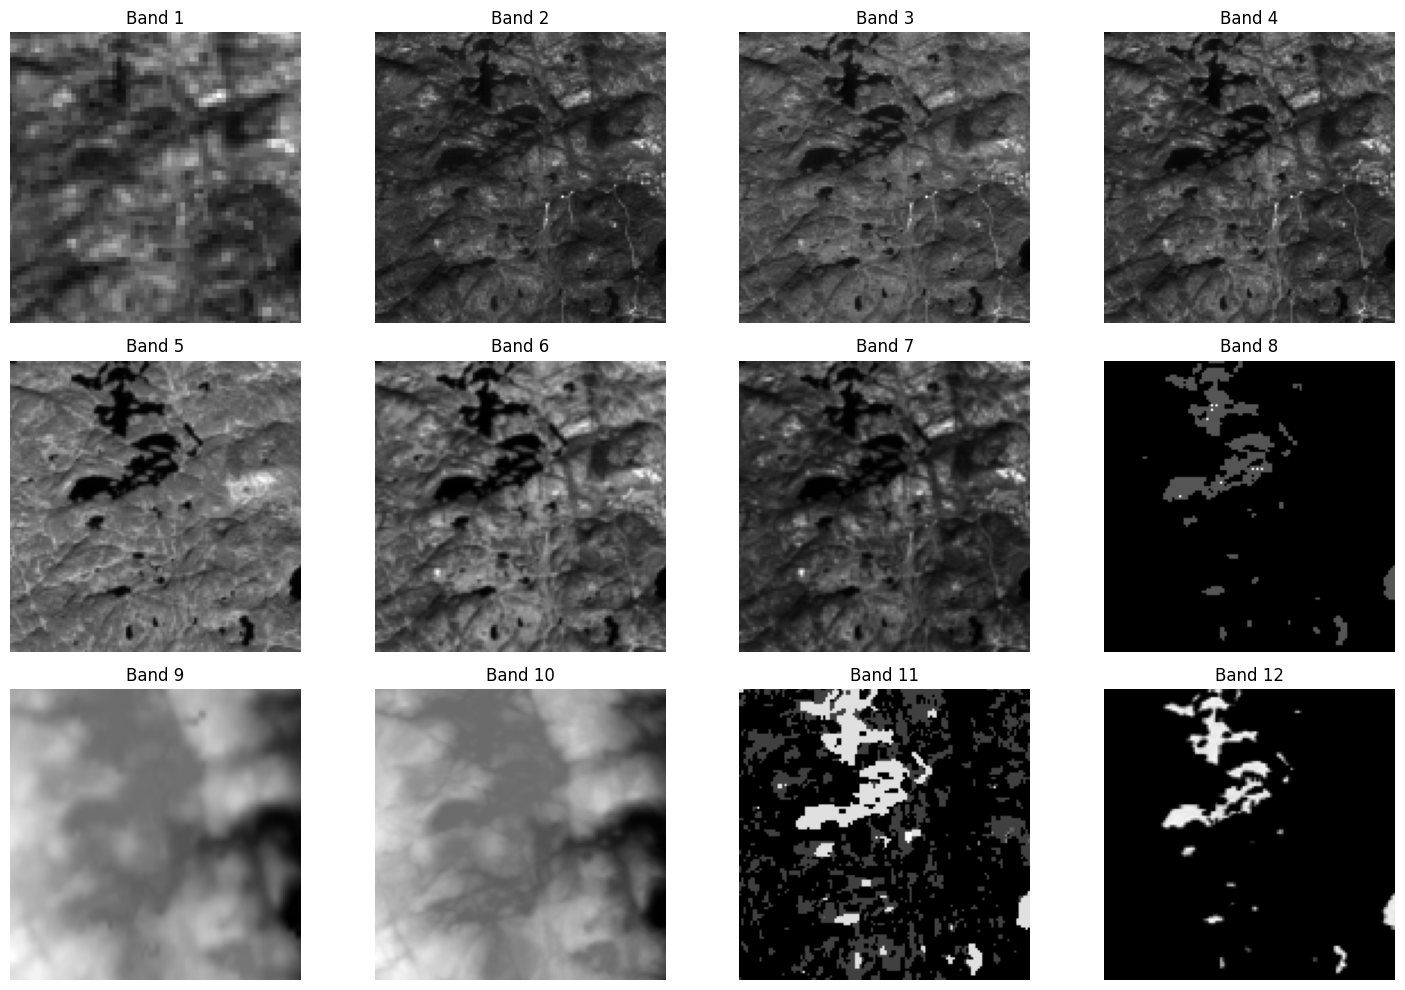

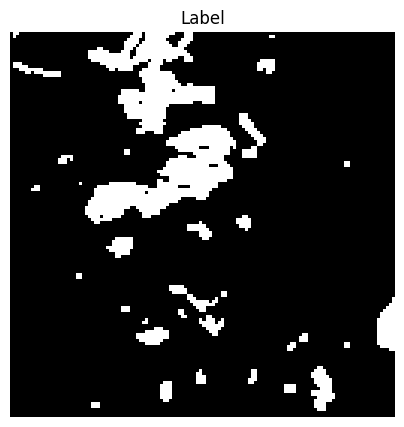

In [24]:
# Get first image and label file
image_files = sorted(os.listdir(IMAGE_DIR))
label_files = sorted(os.listdir(LABEL_DIR))

image_path = os.path.join(IMAGE_DIR, image_files[0])
label_path = os.path.join(LABEL_DIR, label_files[0])

# Read multispectral TIFF image
with rasterio.open(image_path) as src:
    image = src.read()  # Shape: (bands, height, width)

# Read label image
label = np.array(Image.open(label_path))

print("Image shape:", image.shape)  # (bands, H, W)
print("Label shape:", label.shape)

num_bands = image.shape[0]

# Create subplot grid for bands visualization
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i in range(num_bands):
    band = image[i]

    # Normalize band for visualization only
    band_min = band.min()
    band_max = band.max()
    
    if band_max != band_min:
        band_vis = (band - band_min) / (band_max - band_min)
    else:
        band_vis = band  # Avoid division by zero

    axes[i].imshow(band_vis, cmap="gray")
    axes[i].set_title(f"Band {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Visualize label
plt.figure(figsize=(5, 5))
plt.imshow(label, cmap="gray")
plt.title("Label")
plt.axis("off")
plt.show()

In [25]:
import os

image_files = set([f.replace(".tif", "") for f in os.listdir(IMAGE_DIR)])
label_files = set([f.replace(".png", "") for f in os.listdir(LABEL_DIR)])

print("Images count:", len(image_files))
print("Labels count:", len(label_files))

print("Labels without images:")
print(label_files - image_files)

print("Images without labels:")
print(image_files - label_files)

Images count: 306
Labels count: 456
Labels without images:
{'79_161', '10_244', '75_52', '74_65', '133_224', '115_49', '117_97', '124_95', '112_78', '62_187', '26_274', '70_268', '88_157', '127_54', '84_76', '69_18', '24_111', '44_191', '4_300', '29_186', '110_287', '56_19', '107_59', '91_102', '34_239', '55_219', '77_61', '23_251', '21_254', '14_135', '144_235', '92_272', '140_34', '12_286', '5_275', '7_146', '22_16', '43_149', '36_240', '131_185', '106_267', '15_233', '119_222', '2_215', '28_2', '125_201', '47_15', '128_294', '52_160', '126_110', '27_290', '76_92', '11_116', '32_11', '130_256', '83_131', '68_180', '37_118', '95_221', '31_196', '109_223', '141_237', '33_134', '19_293', '54_51', '108_236', '86_288', '65_203', '148_297', '78_246', '105_148', '42_281', '25_172', '49_64', '147_213', '97_130', '13_234', '16_229', '87_182', '116_250', '103_225', '93_217', '41_77', '96_154', '35_30', '45_158', '30_143', '59_132', '137_140', '94_119', '120_305', '134_153', '102_179', '1_226',

In [26]:
def load_data(image_dir, label_dir):
    images = []
    masks = []
    
    image_files = sorted(os.listdir(image_dir))
    
    for file in image_files:
        if file.endswith(".tif"):
            image_path = os.path.join(image_dir, file)
            label_path = os.path.join(label_dir, file.replace(".tif", ".png"))
            
            # Read multispectral image (12 bands)
            with rasterio.open(image_path) as src:
                image = src.read()  # (bands, H, W)
                image = np.transpose(image, (1, 2, 0))  # (H, W, bands)
            
            # Read mask
            mask = Image.open(label_path)
            mask = np.array(mask)
            
            # Ensure binary
            mask = (mask > 0).astype(np.float32)
            mask = np.expand_dims(mask, axis=-1)
            
            images.append(image)
            masks.append(mask)
    
    return np.array(images), np.array(masks)

In [27]:
X, y = load_data(IMAGE_DIR, LABEL_DIR)
print("Data shape:", X.shape, y.shape)

Data shape: (306, 128, 128, 12) (306, 128, 128, 1)


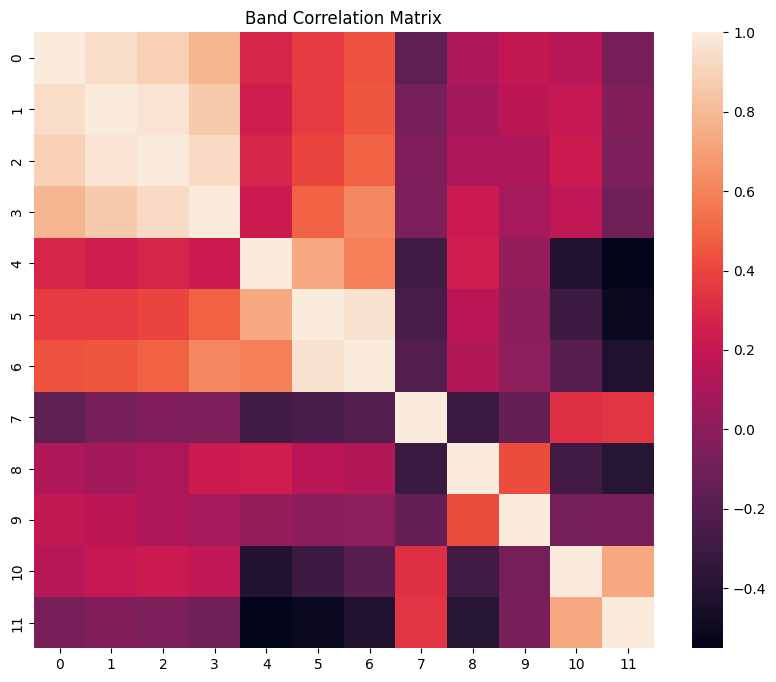

In [28]:
import seaborn as sns

X_flat = X.reshape(-1, 12)

corr_matrix = np.corrcoef(X_flat, rowvar=False)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False)
plt.title("Band Correlation Matrix")
plt.show()

In [29]:
from sklearn.model_selection import train_test_split

test_ratio = 0.15

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=test_ratio,
    random_state=42,
    shuffle=True
)


val_ratio = 0.2

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_ratio,
    random_state=42,
    shuffle=True
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (208, 128, 128, 12)
Validation: (52, 128, 128, 12)
Test: (46, 128, 128, 12)


In [30]:
# Standardization (Z-score) based on training data

means = X_train.mean(axis=(0,1,2))
stds  = X_train.std(axis=(0,1,2))

def normalize(X, means, stds):
    return (X - means) / (stds + 1e-8)

# Apply normalization
X_train = normalize(X_train, means, stds)
X_val   = normalize(X_val, means, stds)
X_test  = normalize(X_test, means, stds)

print("After Z-score normalization:")
print("Min:", X_train.min(), "Max:", X_train.max())
print("Mean per band:", X_train.mean(axis=(0,1,2)))

After Z-score normalization:
Min: -7.171619697080086 Max: 28.84644096647968
Mean per band: [-2.39832153e-15  1.50806430e-16 -1.88958521e-16 -3.71903045e-15
  5.46801622e-16  1.50199590e-15  1.60353641e-15  1.55983313e-13
  2.46247078e-13 -6.33692179e-14  2.51924557e-13  1.15591329e-13]


In [31]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 16

# Augmentation configuration
data_gen_args = dict(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=90
)

# Single generator for both image and mask
image_mask_datagen = ImageDataGenerator(**data_gen_args)

def segmentation_generator(X, y, batch_size):
    """
    Generator that applies identical augmentation to image and mask.
    """

    # Create same seed for synchronization
    seed = 42

    image_generator = image_mask_datagen.flow(
        X,
        batch_size=batch_size,
        seed=seed
    )

    mask_generator = image_mask_datagen.flow(
        y,
        batch_size=batch_size,
        seed=seed
    )

    while True:
        X_batch = next(image_generator)
        y_batch = next(mask_generator)

        yield X_batch, y_batch


# Create training generator
train_generator = segmentation_generator(
    X_train,
    y_train,
    BATCH_SIZE
)

steps_per_epoch = len(X_train) // BATCH_SIZE

print("Steps per epoch:", steps_per_epoch)

Steps per epoch: 13


# EfficientNetB0

In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 12


# Custom IoU for Water Only 
def water_iou(y_true, y_pred):

    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection

    return intersection / (union + 1e-7)


#  Model 
def build_model():

    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS))

    # 12 → 3 channels (spectral projection)
    x = layers.Conv2D(3, (1,1), padding="same")(inputs)

    # Rescale 0–1 → 0–255 (to be closer to ImageNet distribution)
    x = layers.Rescaling(255.0)(x)

    # Pretrained Backbone
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights="imagenet"
    )

    # No freezing (FULL fine-tuning)
    base_model.trainable = True

    x = base_model(x)

    #  Decoder 
    x = layers.UpSampling2D((2,2), interpolation="bilinear")(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D((2,2), interpolation="bilinear")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D((2,2), interpolation="bilinear")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D((2,2), interpolation="bilinear")(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D((2,2), interpolation="bilinear")(x)
    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    return models.Model(inputs, outputs)


model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[water_iou]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 3)    │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 8, 8, 1280)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_13 (UpSampling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_14 (UpSampling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 128, 128, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 1)    │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,390,923 (28.19 MB)

 Trainable params: 7,348,900 (28.03 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [36]:
EPOCHS = 30
BATCH_SIZE = 8

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 95s 632ms/step - loss: 0.5954 - water_iou: 0.0463 - val_loss: 0.4450 - val_water_iou: 0.3565
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.4351 - water_iou: 0.4223 - val_loss: 0.3792 - val_water_iou: 0.5146
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.3710 - water_iou: 0.5360 - val_loss: 0.3640 - val_water_iou: 0.5325
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.3188 - water_iou: 0.5798 - val_loss: 0.3160 - val_water_iou: 0.5706
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.2958 - water_iou: 0.6241 - val_loss: 0.3125 - val_water_iou: 0.5305
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.2595 - water_iou: 0.6303 - val_loss: 0.2821 - val_water_iou: 0.5878
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.2966 - water_iou: 0.6057 - val_loss: 0.2768 - val_water_iou: 0.5792
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.2607 - water_iou: 0.6423 - val_los

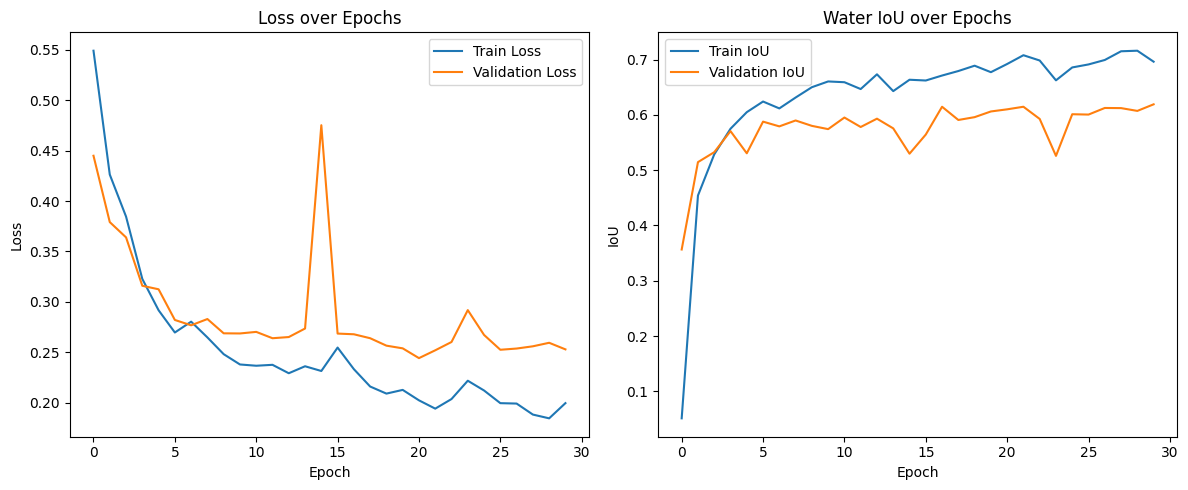

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

#  Loss Plot 
plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])

# IoU Plot 
plt.subplot(1,2,2)
plt.plot(history.history['water_iou'])
plt.plot(history.history['val_water_iou'])
plt.title("Water IoU over Epochs")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend(["Train IoU", "Validation IoU"])

plt.tight_layout()
plt.show()

In [38]:
import numpy as np

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(np.uint8)

y_true = y_test.astype(np.uint8)

2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 8s/step


In [39]:
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true_flat, y_pred_flat)
recall = recall_score(y_true_flat, y_pred_flat)
f1 = f1_score(y_true_flat, y_pred_flat)

# IoU (Water only)
intersection = np.logical_and(y_true_flat == 1, y_pred_flat == 1).sum()
union = np.logical_or(y_true_flat == 1, y_pred_flat == 1).sum()
iou = intersection / (union + 1e-7)



print("========== Test Metrics ==========")
print("IoU (Water):", iou)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


========== Test Metrics ==========
IoU (Water): 0.6630634543168833
Precision: 0.7935738236953366
Recall: 0.8012633842569777
F1-score: 0.7974000662403505


# #mobile net

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 12


# Model Architecture

def build_model():

    inputs = layers.Input(shape=(128,128,12))

    # Projection layer (12 → 3 channels)
    x = layers.Conv2D(3, (1,1), padding="same")(inputs)

    # Pretrained backbone
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(128,128,3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    # Decoder (Upsampling Path)

    x = layers.UpSampling2D(size=(2,2), interpolation="bilinear")(x)
    x = layers.Conv2D(256,3,padding="same",activation="relu")(x)

    x = layers.UpSampling2D(size=(2,2), interpolation="bilinear")(x)
    x = layers.Conv2D(128,3,padding="same",activation="relu")(x)

    x = layers.UpSampling2D(size=(2,2), interpolation="bilinear")(x)
    x = layers.Conv2D(64,3,padding="same",activation="relu")(x)

    x = layers.UpSampling2D(size=(2,2), interpolation="bilinear")(x)
    x = layers.Conv2D(32,3,padding="same",activation="relu")(x)

    # Extra Upsampling to match label size (128x128)
    x = layers.UpSampling2D(size=(2,2), interpolation="bilinear")(x)
    x = layers.Conv2D(16,3,padding="same",activation="relu")(x)

    # Final Output (128×128)
    outputs = layers.Conv2D(1,1,activation="sigmoid")(x)

    return models.Model(inputs, outputs)


# Compile Model


model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.MeanIoU(num_classes=2)]
)

model.summary()



Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 128, 128, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 3)    │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 8, 8, 1280)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_13 (UpSampling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_14 (UpSampling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 128, 128, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 128, 128, 1)    │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,599,336 (21.36 MB)

 Trainable params: 3,341,352 (12.75 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
EPOCHS = 50

history = model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    steps_per_epoch=len(X_train)//16
)

Epoch 1/50


I0000 00:00:1772223613.672832     225 service.cc:152] XLA service 0x7d4058001a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772223613.672880     225 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772223615.173208     225 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772223627.036464     225 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - loss: 0.5625 - mean_io_u_4: 0.3801 - val_loss: 0.4266 - val_mean_io_u_4: 0.3765
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 253ms/step - loss: 0.4615 - mean_io_u_4: 0.3855 - val_loss: 0.3726 - val_mean_io_u_4: 0.3765
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 272ms/step - loss: 0.3872 - mean_io_u_4: 0.3721 - val_loss: 0.3605 - val_mean_io_u_4: 0.3765
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - loss: 0.3660 - mean_io_u_4: 0.3683 - val_loss: 0.3421 - val_mean_io_u_4: 0.3765
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step - loss: 0.3459 - mean_io_u_4: 0.3627 - val_loss: 0.3428 - val_mean_io_u_4: 0.3765
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 279ms/step - loss: 0.3291 - mean_io_u_4: 0.3707 - val_loss: 0.3350 - val_mean_io_u_4: 0.3765
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 270ms/step - loss: 0.3156 - mean_io_u_4: 0.3762 - val_loss: 0.3361 - val_mean_io_u_4: 0.3765
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 273ms/step - loss: 0.3273 - mean_i

In [25]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 0.2441 - mean_io_u_4: 0.4016


[0.2455170452594757, 0.3963417410850525]

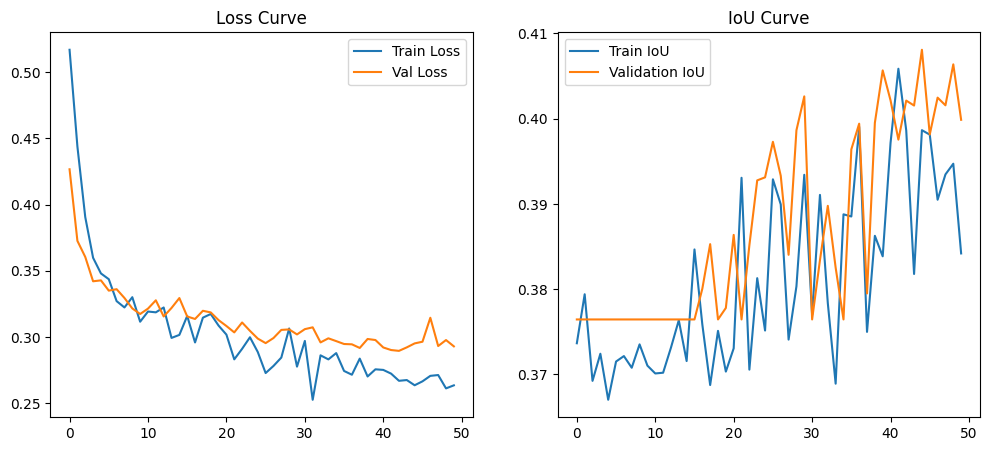

In [31]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)

plt.plot(history.history['mean_io_u_4'], label='Train IoU')
plt.plot(history.history['val_mean_io_u_4'], label='Validation IoU')

plt.legend()
plt.title("IoU Curve")

plt.show()

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

# Predict test masks
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(np.float32)

# Flatten arrays
y_true_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()

# Metrics
precision = precision_score(y_true_flat, y_pred_flat)
recall = recall_score(y_true_flat, y_pred_flat)
iou = jaccard_score(y_true_flat, y_pred_flat)
f1 = f1_score(y_true_flat, y_pred_flat)

print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test IoU:", iou)
print("Test F1 Score:", f1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Test Precision: 0.7325697211155379
Test Recall: 0.781410203075899
Test IoU: 0.6079783684729456
Test F1 Score: 0.7562021733542679
